### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [510]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [511]:
data = pd.read_csv('data/coupons.csv')

In [512]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [513]:
data.info() # get dataframe info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [514]:
# set the appropriate column datatypes
data = data.convert_dtypes()

#cleanup column names - remove all capital letters and add '_' between words of a column name
# convert all column names to small letters
for c in data.columns:
    data.rename(columns = {c:c.lower()}, inplace=True)

# add '_' to column names with more than 1 words
data.rename(columns={'maritalstatus':'marital_status', 
                   'coffeehouse':'coffee_house', 
                   'carryaway':'carry_away',
                   'restaurantlessthan20':'restaurant_less_than_20',
                   'restaurant20to50':'restaurant_20_to_50',
                   'tocoupon_geq5min':'tocoupon_geq_5min',
                   'tocoupon_geq15min':'tocoupon_geq_15min',
                   'tocoupon_geq25min':'tocoupon_geq_25min',
                   'y':'coupon_accepted'}, inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   destination              12684 non-null  string
 1   passanger                12684 non-null  string
 2   weather                  12684 non-null  string
 3   temperature              12684 non-null  Int64 
 4   time                     12684 non-null  string
 5   coupon                   12684 non-null  string
 6   expiration               12684 non-null  string
 7   gender                   12684 non-null  string
 8   age                      12684 non-null  string
 9   marital_status           12684 non-null  string
 10  has_children             12684 non-null  Int64 
 11  education                12684 non-null  string
 12  occupation               12684 non-null  string
 13  income                   12684 non-null  string
 14  car                      108 non-null 

In [515]:
# check for duplicate values 
print(f"Number of rows that are duplicated: {data.duplicated().sum()}")

# NOTE: There are only 74 duplicated rows out of 12884 rows (less than 1%). 
# I am chosing to ignore these rows and not drop them as there are no other monikers to concretely
# identify whether the duplicate entries are really duplicates or just a coincidence
 

Number of rows that are duplicated: 74


In [516]:
# describe the dataframe to get more information. Transposing it here so that output is not truncated
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
destination,12684,3,No Urgent Place,6283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
passanger,12684,4,Alone,7305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,12684,3,Sunny,10069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,12684.0,<NA>,<NA>,<NA>,63.301798,19.154486,30.0,55.0,80.0,80.0,80.0
time,12684,5,6PM,3230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coupon,12684,5,Coffee House,3996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expiration,12684,2,1d,7091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,12684,2,Female,6511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,12684,8,21,2653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,12684,5,Married partner,5100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [517]:
# columns that contain missing values
data.isnull().sum()

destination                    0
passanger                      0
weather                        0
temperature                    0
time                           0
coupon                         0
expiration                     0
gender                         0
age                            0
marital_status                 0
has_children                   0
education                      0
occupation                     0
income                         0
car                        12576
bar                          107
coffee_house                 217
carry_away                   151
restaurant_less_than_20      130
restaurant_20_to_50          189
tocoupon_geq_5min              0
tocoupon_geq_15min             0
tocoupon_geq_25min             0
direction_same                 0
direction_opp                  0
coupon_accepted                0
dtype: int64

In [518]:
# Define a function to print missing data and % of missed values in each column for a given dataframe

def print_missing_data(df):    
    # print list of columns with missing values and their count
    dict_na_columns = data.isnull().sum()[data.isnull().sum()>0].to_dict()
    print("Columns with missing values and their counts:\n", dict_na_columns)

    # Percentage of missing values per column
    dict_percentage_missing = ((data.isnull().mean()*100).round(2))[data.isnull().sum()>0].to_dict()
    print("Coulumns with missing values and the '%' of missing values:\n", dict_percentage_missing)

# get more infromation on the columns with missig data
print_missing_data(data)

Columns with missing values and their counts:
 {'car': 12576, 'bar': 107, 'coffee_house': 217, 'carry_away': 151, 'restaurant_less_than_20': 130, 'restaurant_20_to_50': 189}
Coulumns with missing values and the '%' of missing values:
 {'car': 99.15, 'bar': 0.84, 'coffee_house': 1.71, 'carry_away': 1.19, 'restaurant_less_than_20': 1.02, 'restaurant_20_to_50': 1.49}


3. Decide what to do about your missing data -- drop, replace, other...

In [519]:
# from above, # of missing values for the column 'car' is > 99%, and it doesn't appear to have any impact on
# issueing coupons. Hence dropping it
data = data.drop(columns='car')

# check the column is dropped
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   destination              12684 non-null  string
 1   passanger                12684 non-null  string
 2   weather                  12684 non-null  string
 3   temperature              12684 non-null  Int64 
 4   time                     12684 non-null  string
 5   coupon                   12684 non-null  string
 6   expiration               12684 non-null  string
 7   gender                   12684 non-null  string
 8   age                      12684 non-null  string
 9   marital_status           12684 non-null  string
 10  has_children             12684 non-null  Int64 
 11  education                12684 non-null  string
 12  occupation               12684 non-null  string
 13  income                   12684 non-null  string
 14  bar                      12577 non-nul

In [520]:
# rows that contain at least 1 missing value
data[data.isnull().sum(axis=1)>0]

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,marital_status,...,coffee_house,carry_away,restaurant_less_than_20,restaurant_20_to_50,tocoupon_geq_5min,tocoupon_geq_15min,tocoupon_geq_25min,direction_same,direction_opp,coupon_accepted
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,<NA>,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,<NA>,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,<NA>,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,<NA>,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,<NA>,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12409,Home,Alone,Sunny,80,6PM,Restaurant(20-50),1d,Female,36,Married partner,...,<NA>,1~3,1~3,1~3,1,0,0,1,0,1
12410,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Female,36,Married partner,...,<NA>,1~3,1~3,1~3,1,0,0,0,1,1
12411,Work,Alone,Snowy,30,7AM,Coffee House,1d,Female,36,Married partner,...,<NA>,1~3,1~3,1~3,1,0,0,1,0,0
12412,Work,Alone,Snowy,30,7AM,Bar,1d,Female,36,Married partner,...,<NA>,1~3,1~3,1~3,1,1,1,0,1,0


In [521]:
#rows that contain more than one missing values
data[data.isnull().sum(axis=1)>1]

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,marital_status,...,coffee_house,carry_away,restaurant_less_than_20,restaurant_20_to_50,tocoupon_geq_5min,tocoupon_geq_15min,tocoupon_geq_25min,direction_same,direction_opp,coupon_accepted
517,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,0,0,0,1,0
518,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,0,0,0,1,0
519,No Urgent Place,Friend(s),Sunny,80,2PM,Restaurant(<20),1d,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,1,0,0,1,1
520,No Urgent Place,Friend(s),Sunny,80,6PM,Coffee House,2h,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,0,0,0,1,0
521,No Urgent Place,Friend(s),Sunny,55,2PM,Coffee House,2h,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3355,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,0,0,0,1,1
3356,No Urgent Place,Friend(s),Sunny,80,2PM,Restaurant(<20),1d,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,1,0,0,1,1
3357,No Urgent Place,Friend(s),Sunny,80,6PM,Coffee House,2h,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,0,0,0,1,1
3358,No Urgent Place,Friend(s),Sunny,55,2PM,Coffee House,2h,Male,50plus,Divorced,...,<NA>,<NA>,<NA>,<NA>,1,0,0,0,1,1


In [522]:
# list of coloumns that contain null/na vlaues
na_col_names = data.isnull().sum()[data.isnull().sum()>0].keys().to_list()

# fill na vlaues with mode()
for col in na_col_names:
    data[col] = data[col].fillna(data[col].mode()[0])

data.to_csv('data/cleaned_coupons.csv', index=False) # save the cleaned up dataset
data.isnull().sum() # check to make sure there are no na vlues

destination                0
passanger                  0
weather                    0
temperature                0
time                       0
coupon                     0
expiration                 0
gender                     0
age                        0
marital_status             0
has_children               0
education                  0
occupation                 0
income                     0
bar                        0
coffee_house               0
carry_away                 0
restaurant_less_than_20    0
restaurant_20_to_50        0
tocoupon_geq_5min          0
tocoupon_geq_15min         0
tocoupon_geq_25min         0
direction_same             0
direction_opp              0
coupon_accepted            0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?


In [523]:
# define a helper function to calculate pie chart labels
def make_piechart_label(rate, values):
    count = int(round(rate / 100 * sum(values)))
    return f'{rate:.1f}%\n(total:{count:,})'

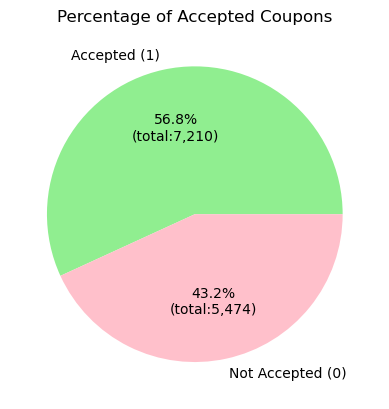

In [524]:
# chart the porportion of total observations that chose to accept the coupon
ncoupons = data['coupon_accepted'].value_counts()

plt.pie(ncoupons, 
        labels=['Accepted (1)', 'Not Accepted (0)'], 
        colors = ['lightgreen', 'pink'],
        autopct=lambda rate: make_piechart_label(rate, ncoupons))
plt.title("Percentage of Accepted Coupons")
plt.show()

5. Use a bar plot to visualize the `coupon` column.

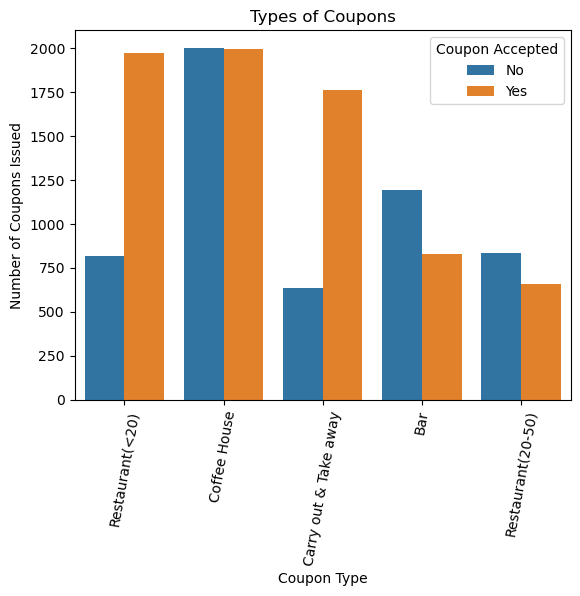

In [525]:
fig_coupons = sns.countplot(data,x='coupon', hue='coupon_accepted')
plt.xticks(rotation=80)
plt.title('Types of Coupons')
plt.xlabel('Coupon Type')
plt.ylabel("Number of Coupons Issued")
fig_coupons.legend(handles=fig_coupons.legend_.legend_handles, labels=['No', 'Yes'], title='Coupon Accepted')
plt.show()

6. Use a histogram to visualize the temperature column.

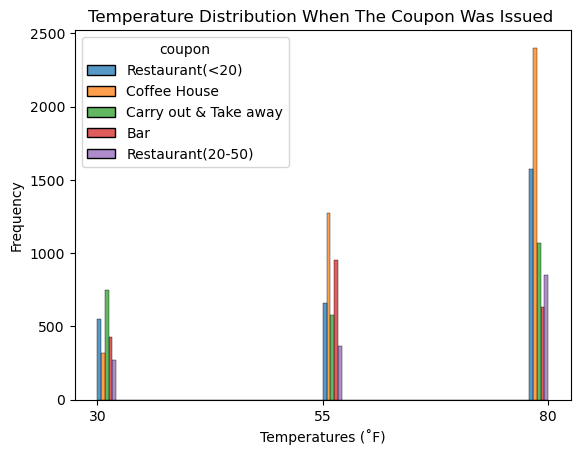

In [526]:
fig_temp = sns.histplot(data, x='temperature', color='green', hue='coupon', multiple='dodge')
plt.title("Temperature Distribution When The Coupon Was Issued ")
plt.xlabel("Temperatures (˚F)")
plt.ylabel("Frequency")
plt.xticks(data['temperature'].unique())
plt.show()


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [527]:
df_bar_coupon = data.query('coupon == "Bar"')
df_bar_coupon.info()
'''
print(df_bar_coupon.info(), "\n\n")
for x in df_bar_coupon.columns:
    print(f"Unique values of '{x}': \n{df_bar_coupon[x].unique()}")
'''

<class 'pandas.core.frame.DataFrame'>
Index: 2017 entries, 9 to 12682
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   destination              2017 non-null   string
 1   passanger                2017 non-null   string
 2   weather                  2017 non-null   string
 3   temperature              2017 non-null   Int64 
 4   time                     2017 non-null   string
 5   coupon                   2017 non-null   string
 6   expiration               2017 non-null   string
 7   gender                   2017 non-null   string
 8   age                      2017 non-null   string
 9   marital_status           2017 non-null   string
 10  has_children             2017 non-null   Int64 
 11  education                2017 non-null   string
 12  occupation               2017 non-null   string
 13  income                   2017 non-null   string
 14  bar                      2017 non-null   str

'\nprint(df_bar_coupon.info(), "\n\n")\nfor x in df_bar_coupon.columns:\n    print(f"Unique values of \'{x}\': \n{df_bar_coupon[x].unique()}")\n'

In [528]:
df_bar_coupon.head().T

,9,13,17,24,35
destination,No Urgent Place,Home,Work,No Urgent Place,Home
passanger,Kid(s),Alone,Alone,Friend(s),Alone
weather,Sunny,Sunny,Sunny,Sunny,Sunny
temperature,80,55,55,80,55
time,10AM,6PM,7AM,10AM,6PM
coupon,Bar,Bar,Bar,Bar,Bar
expiration,1d,1d,1d,1d,1d
gender,Female,Female,Female,Male,Male
age,21,21,21,21,21
marital_status,Unmarried partner,Unmarried partner,Unmarried partner,Single,Single


In [529]:
# Helper function to plot bar graph. 
def plotacceptancerates(labelslist, rateslist, sumlist, totalcouponslist, colorslist, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    ax.bar(labelslist, rateslist, color=colorslist)

    for i in range(len(rateslist)):
        ax.text(
            i,
            rateslist[i],
            f"{rateslist[i]:.2f}% (n={sumlist[i]}/{totalcouponslist[i]})",
            ha='center',
            va='bottom'
        )

    ax.set_ylabel("Acceptance Rate")
    ax.set_title(title)

    return fig, ax

2. What proportion of bar coupons were accepted?


In [530]:
print(f"Porportion of bar coupons accepted = {df_bar_coupon['coupon_accepted'].mean().round(2)}")
nbarcoupons = df_bar_coupon['coupon_accepted'].value_counts()
print(nbarcoupons)

Porportion of bar coupons accepted = 0.41
coupon_accepted
0    1190
1     827
Name: count, dtype: Int64


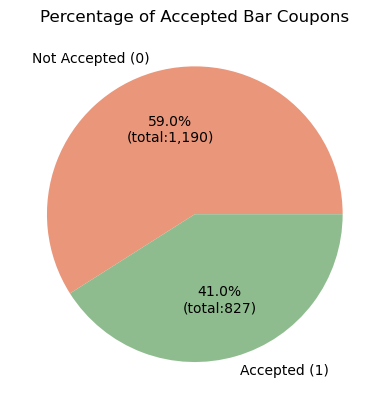

In [531]:
# plot the graph
plt.pie(nbarcoupons, 
        labels=['Not Accepted (0)', 'Accepted (1)'], 
        colors = ['darksalmon', 'darkseagreen'],
        autopct=lambda pct: make_piechart_label(pct, nbarcoupons))
plt.title("Percentage of Accepted Bar Coupons")
plt.show()

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [532]:
# group bar column values
bar_3orless = ['never', 'less1', '1~3']
bar_morethan3 = ['gt8', '4~8']

# query the dataframe to obtain sub df for the groups <=3 bar & > 3 bar goers
df_bar_3orless = df_bar_coupon.query('bar in @bar_3orless')
df_bar_morethan3 = df_bar_coupon.query('bar in @bar_morethan3')

# compute acceptance rates for the groups
acptrate_3orless = (df_bar_3orless['coupon_accepted'].mean()*100).round(2)
acptrate_morethan3 = (df_bar_morethan3['coupon_accepted'].mean()*100).round(2)


# Acceptance rate between those who went to a bar 3 or fewer andm ore than 3
print(f"Coupon acceptance rate for people who went to bar <=3 times is {acptrate_3orless}%")
print(f"Coupon acceptance rate for people who went to bar >3 times is {acptrate_morethan3}%")
print(f"People who went to bar >3 times are {(acptrate_morethan3 - acptrate_3orless).round(2)}% more likely to accept the coupon.")


Coupon acceptance rate for people who went to bar <=3 times is 37.07%
Coupon acceptance rate for people who went to bar >3 times is 76.88%
People who went to bar >3 times are 39.81% more likely to accept the coupon.


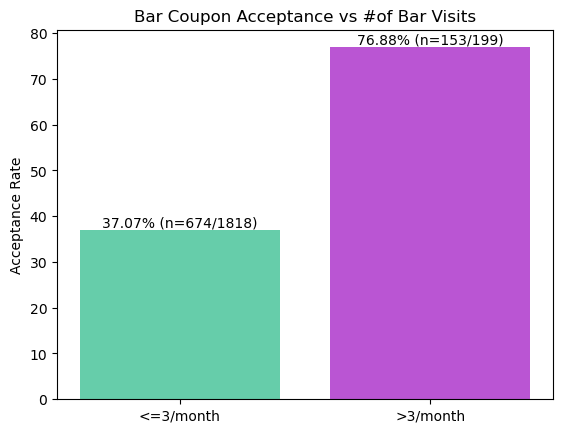

In [533]:
# plot a graph showing the comparision of acceptance rate between thos who went to bar <=3/M vs >3/M

labels = ['<=3/month', '>3/month']
acpt_rates = [acptrate_3orless,acptrate_morethan3 ]
sum_accepted = [df_bar_3orless['coupon_accepted'].sum(), df_bar_morethan3['coupon_accepted'].sum()]
total_coupons = [len(df_bar_3orless),len(df_bar_morethan3)]

fig, ax = plotacceptancerates(labels, 
                       acpt_rates, 
                       sum_accepted, 
                       total_coupons, 
                       ['mediumaquamarine', 'mediumorchid'],
                       'Bar Coupon Acceptance vs #of Bar Visits')
plt.show()


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [534]:
age_above25 = ['46', '26', '31', '41', '36', '50plus']
visits_morethan1 = ['1~3', '4~8', 'gt8']

# sub dataframes for the groups (age 25 & visits bar >1) and all others
df_abv25_gt1 = df_bar_coupon.query("age in @age_above25 and bar in @visits_morethan1")
df_remaining = df_bar_coupon.drop(index = df_abv25_gt1.index)

acptrate_above25_gt1 = df_abv25_gt1['coupon_accepted'].mean()*100
acptrate_allothers = df_remaining['coupon_accepted'].mean()*100
print(f"Acceptance rate of drivers who go to bar >=1 and aged >25 = {acptrate_above25_gt1.round(2)}%")
print(f"Acceptance rate of all other drivers = {acptrate_allothers.round(2)}%")


Acceptance rate of drivers who go to bar >=1 and aged >25 = 69.52%
Acceptance rate of all other drivers = 33.5%


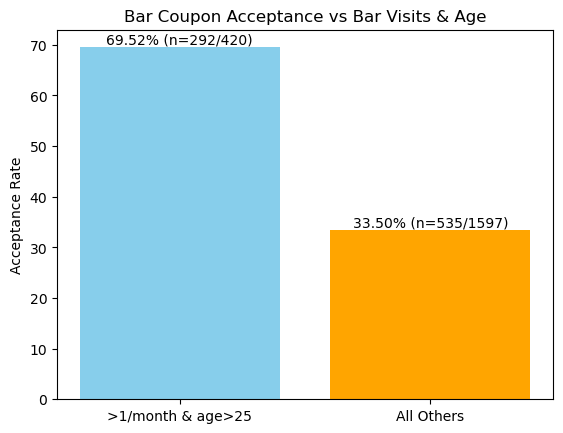

In [535]:
# plot the comparison of acceptance rates
labels = ['>1/month & age>25', 'All Others']
acpt_rates = [acptrate_above25_gt1, acptrate_allothers]
sum_accepted = [df_abv25_gt1['coupon_accepted'].sum(), df_remaining['coupon_accepted'].sum()]
total_coupons = [len(df_abv25_gt1), len(df_remaining)]

fig, ax = plotacceptancerates(labels, 
                       acpt_rates, 
                       sum_accepted, 
                       total_coupons, 
                       ['skyblue', 'orange'],
                       'Bar Coupon Acceptance vs Bar Visits & Age')

plt.show()


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [536]:
# filtered_occupation_list = list(filter(lambda x: x!= 'Farming Fishing & Forestry', df_bar_coupon['occupation'].unique()))

# create a dataframe for drivers wth bar visits >1, passengers !=kid and occupation!= farming, fishing or forestry 
visits_morethan1 = ['1~3', '4~8', 'gt8']
df_group = df_bar_coupon.query("bar in @visits_morethan1 and passanger != 'Kid(s)' and occupation !=  'Farming Fishing & Forestry'")

# dataframe for others
df_remaining = df_bar_coupon.drop(index = df_group.index)

rate_gt1_nokid_noFFF = (df_group['coupon_accepted'].mean()*100).round(2)
rate_allothers = (df_remaining['coupon_accepted'].mean()*100).round(2)

print("Acceptance rate of drivers who go to bar >=1 and had passengers that were not a kid and had occupation",
       f"other than farming, fishing, or forestry = {rate_gt1_nokid_noFFF}%")
print(f"Acceptance rate of all other drivers = {rate_allothers}%")


Acceptance rate of drivers who go to bar >=1 and had passengers that were not a kid and had occupation other than farming, fishing, or forestry = 71.32%
Acceptance rate of all other drivers = 29.6%


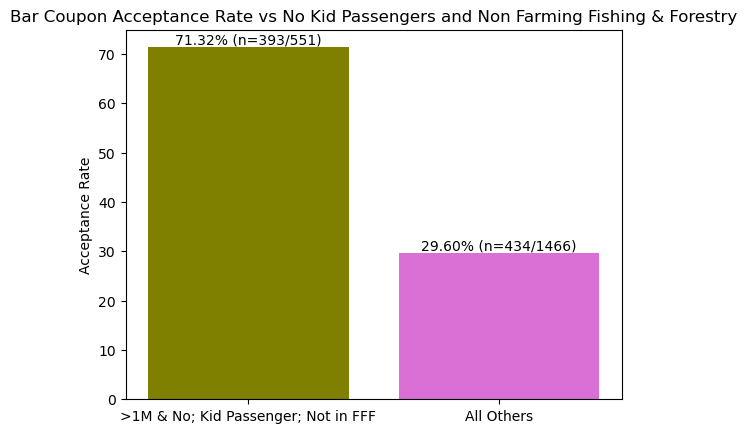

In [537]:
# plot the graph
labels = ['>1M & No; Kid Passenger; Not in FFF', 'All Others']
acpt_rates = [rate_gt1_nokid_noFFF, rate_allothers ]
sum_accepted = [df_group['coupon_accepted'].sum(), df_remaining['coupon_accepted'].sum()]
total_coupons = [len(df_group),len(df_remaining)]

fig, ax = plotacceptancerates(labels, 
                       acpt_rates, 
                       sum_accepted, 
                       total_coupons, 
                       ['olive', 'orchid'],
                       'Bar Coupon Acceptance Rate vs No Kid Passengers and Non Farming Fishing & Forestry')

plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [538]:
visits_morethan1 = ['1~3', '4~8', 'gt8']

# query the dataframe for drivers that go to bar >1, had passangers that were not a kid and were n ot windowed
df_condition1 = df_bar_coupon.query("bar in @visits_morethan1 and passanger != 'Kid(s)' and marital_status !=  'Widowed'")
df_condition1_remaining = df_bar_coupon.drop(index = df_condition1.index)

# query the dataframe for drivers that go to bar >1, aged <=30
age_below30 = ['below21','21', '26',]
df_condition2 = df_bar_coupon.query("bar in ['1~3', '4~8', 'gt8'] and age in @age_below30")
df_condition2_remaining = df_bar_coupon.drop(index = df_condition2.index)

# query the dataframe for drivers that go to cheap restaurants >4 times and income <50K
restaurant_morethan4 = ['4~8', 'gt8']
income_below50 = ['Less than $12500',
                  '$12500 - $24999',
                  '$25000 - $37499',
                  '$37500 - $49999']
df_condition3 = df_bar_coupon.query("restaurant_less_than_20 in @restaurant_morethan4 and income in @income_below50")
df_condition3_remaining = df_bar_coupon.drop(index = df_condition3.index)

# calculate Bar coupon acceptance rate for each of the sub groups above
acptrate_condition1 = (df_condition1['coupon_accepted'].mean()*100).round(2)
naccepted_condition1 = df_condition1['coupon_accepted'].sum()
acptrate_condition2 = (df_condition2['coupon_accepted'].mean()*100).round(2)
naccepted_condition2 = df_condition2['coupon_accepted'].sum()
acptrate_condition3 = (df_condition3['coupon_accepted'].mean()*100).round(2)
naccepted_condition3 = df_condition3['coupon_accepted'].sum()

print(f"Bar coupon acceptance rate for drivers who visit bars >1 and are not with kids as passengers and are not widowed: {acptrate_condition1}")
print(f"Bar coupon acceptance rate for drivers who are below 30 in age and visit bars >1 per month: {acptrate_condition2}")
print(f"Bar coupon acceptance rate for drivers who visit cheap restaurants >4/month and earn <50K: {acptrate_condition3}")


Bar coupon acceptance rate for drivers who visit bars >1 and are not with kids as passengers and are not widowed: 71.32
Bar coupon acceptance rate for drivers who are below 30 in age and visit bars >1 per month: 72.17
Bar coupon acceptance rate for drivers who visit cheap restaurants >4/month and earn <50K: 45.35


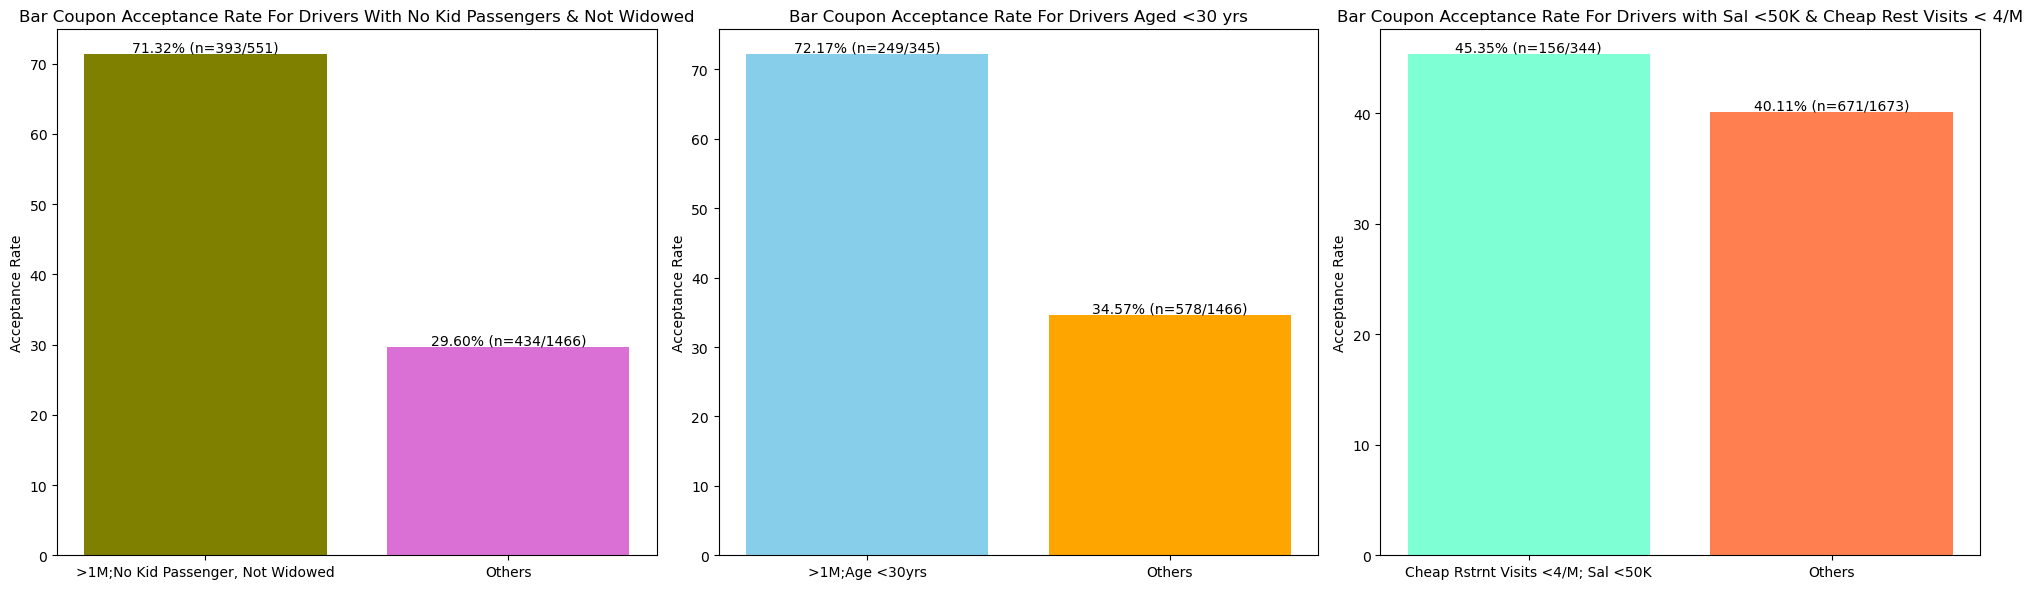

In [539]:
# plot the graphs for the individual condition from question #6 above
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plotacceptancerates(['>1M;No Kid Passenger, Not Widowed','Others'], 
                       [acptrate_condition1, (df_condition1_remaining['coupon_accepted'].mean()*100).round(2)], 
                       [naccepted_condition1, df_condition1_remaining['coupon_accepted'].sum()], 
                       [len(df_condition1), len(df_condition1_remaining)], 
                       ['olive', 'orchid'],
                       'Bar Coupon Acceptance Rate For Drivers With No Kid Passengers & Not Widowed',
                       ax=axes[0])

plotacceptancerates(['>1M;Age <30yrs','Others'], 
                       [acptrate_condition2, (df_condition2_remaining['coupon_accepted'].mean()*100).round(2)], 
                       [naccepted_condition2, df_condition2_remaining['coupon_accepted'].sum()], 
                       [len(df_condition2), len(df_condition1_remaining)], 
                       ['skyblue', 'orange'],
                       'Bar Coupon Acceptance Rate For Drivers Aged <30 yrs',
                       ax=axes[1])

plotacceptancerates(['Cheap Rstrnt Visits <4/M; Sal <50K','Others'], 
                       [acptrate_condition3, (df_condition3_remaining['coupon_accepted'].mean()*100).round(2)], 
                       [naccepted_condition3, df_condition3_remaining['coupon_accepted'].sum()], 
                       [len(df_condition3), len(df_condition3_remaining)], 
                       ['aquamarine', 'coral'],
                       'Bar Coupon Acceptance Rate For Drivers with Sal <50K & Cheap Rest Visits < 4/M',
                       ax=axes[2])

plt.tight_layout()
plt.show()



In [540]:
# combine all conditions and calculate the bar coupon acceptance rates
df_union = df_bar_coupon.loc[
    df_condition1.index.union(df_condition2.index).union(df_condition3.index)
]
df_allothers = df_bar_coupon.drop(index=df_union.index)

coupon_acptrate_union = (df_union['coupon_accepted'].mean()*100).round(2)
coupon_acptrate_allothers = (df_allothers['coupon_accepted'].mean()*100).round(2)

''' 
- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.
'''

print(f"Acceptance rate of bar coupons that meet the conditions = {coupon_acptrate_union}%")
print(f"Acceptance rate of all other drivers = {coupon_acptrate_allothers}%")

Acceptance rate of bar coupons that meet the conditions = 58.89%
Acceptance rate of all other drivers = 29.81%


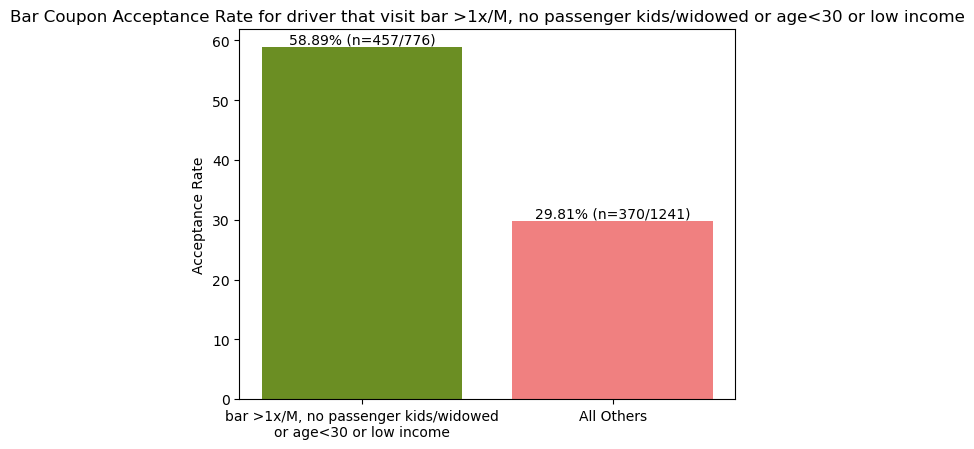

In [541]:
# plot the graph
labels = ['bar >1x/M, no passenger kids/widowed\nor age<30 or low income', 'All Others']
acpt_rates = [coupon_acptrate_union, coupon_acptrate_allothers ]
sum_accepted = [df_union['coupon_accepted'].sum(), df_allothers['coupon_accepted'].sum()]
total_coupons = [len(df_union),len(df_allothers)]

fig, ax = plotacceptancerates(labels, 
                       acpt_rates, 
                       sum_accepted, 
                       total_coupons, 
                       ['olivedrab', 'lightcoral'],
                       'Bar Coupon Acceptance Rate for driver that visit bar >1x/M, no passenger kids/widowed or age<30 or low income')


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

#### Conclusions on Bar Coupon Acceptance
Based on the observations above, I came to the following conclusions about who is more likely to accept bar coupons:

1. **Frequent Bar Goers**: Drivers who frequently visit bars ($\geq 3$ times per month).
2. **Younger Demographic**: People less than 30 years of age.
3. **Passenger Context**: Drivers who are **not** driving kids at the time of receiving the coupon.

Additional Insights:
* **Marital Status**: Non-widowed drivers accept bar coupons **2x more** than others.
* **Income Level**: Low-income drivers accept bar coupons at nearly the same rate as other income brackets.

> **Final Summary**: Overall, the largest group of likely coupon acceptors are **young, frequent bar-goers who do not have children as passengers.**


In [542]:
#print("Based on all the observations above, I came to follwoing conclusions about how is more likely toaccept bar coupons:\n" \
#      "1. Drivers who frequently visit bars (>=3 times per month)\n" \
#      "2. Younger people, less than 30 years of age\n" \
#      "3. Drives who are the driving kids at the time of accepting coupons\n" \
#      "- Non-widowed drivers seem to be accepitng bar coupons 2x times more than the others\n" \
#      "- Low income drivers seem to accept bar coupons almost at the same rate as others\n" \
#      "In conclusion, Overall, drivers are more likely to accept bar coupons and it seems" \
#      " frequent bar goers who are young and do not have kid passengers are the largest group.")

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#### Choosing Coffee House coupon for investigation ####

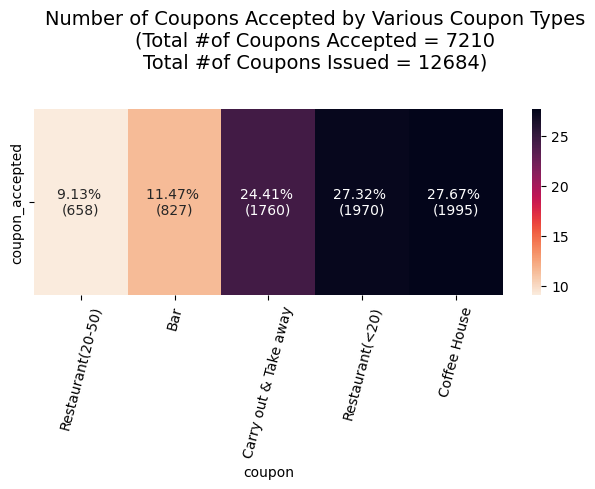

In [543]:

# chart the over all coupon acceptance count vs type of coupons

total_accepted_coupons = data["coupon_accepted"].sum() # total # of CH coupons accepted

counts = data.groupby('coupon')['coupon_accepted'].sum()
counts = counts.sort_values().astype(float)
pivot_table = (counts/counts.sum()*100).to_frame().T

# create readable lables
labels = (
    np.round(counts / counts.sum() * 100, 2).astype(str) +
    '% \n(' +
    counts.astype(int).astype(str) +
    ')'
).to_frame().T

g = sns.heatmap(pivot_table, annot=labels, fmt='', cmap='rocket_r')
g.set_xticklabels(g.get_xticklabels(), rotation = 75)

'''
fig, axes = plt.subplots(len(categories), 1, figsize=(12, 16))

for i, category in enumerate(categories):
    counts = data.groupby(category)['coupon_accepted'].sum()
    counts = counts.sort_values().astype(float)   
    pivot = counts.to_frame().T
  
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Greens', 
                linewidths=0.5, linecolor='white',
                ax=axes[i],
                cbar=False)
    axes[i].set_ylabel(category, rotation=0, labelpad=100, va='center')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
'''
plt.suptitle(f'Number of Coupons Accepted by Various Coupon Types\n' \
             f'(Total #of Coupons Accepted = {total_accepted_coupons}\n' 
             f'Total #of Coupons Issued = {data["coupon_accepted"].count()})', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


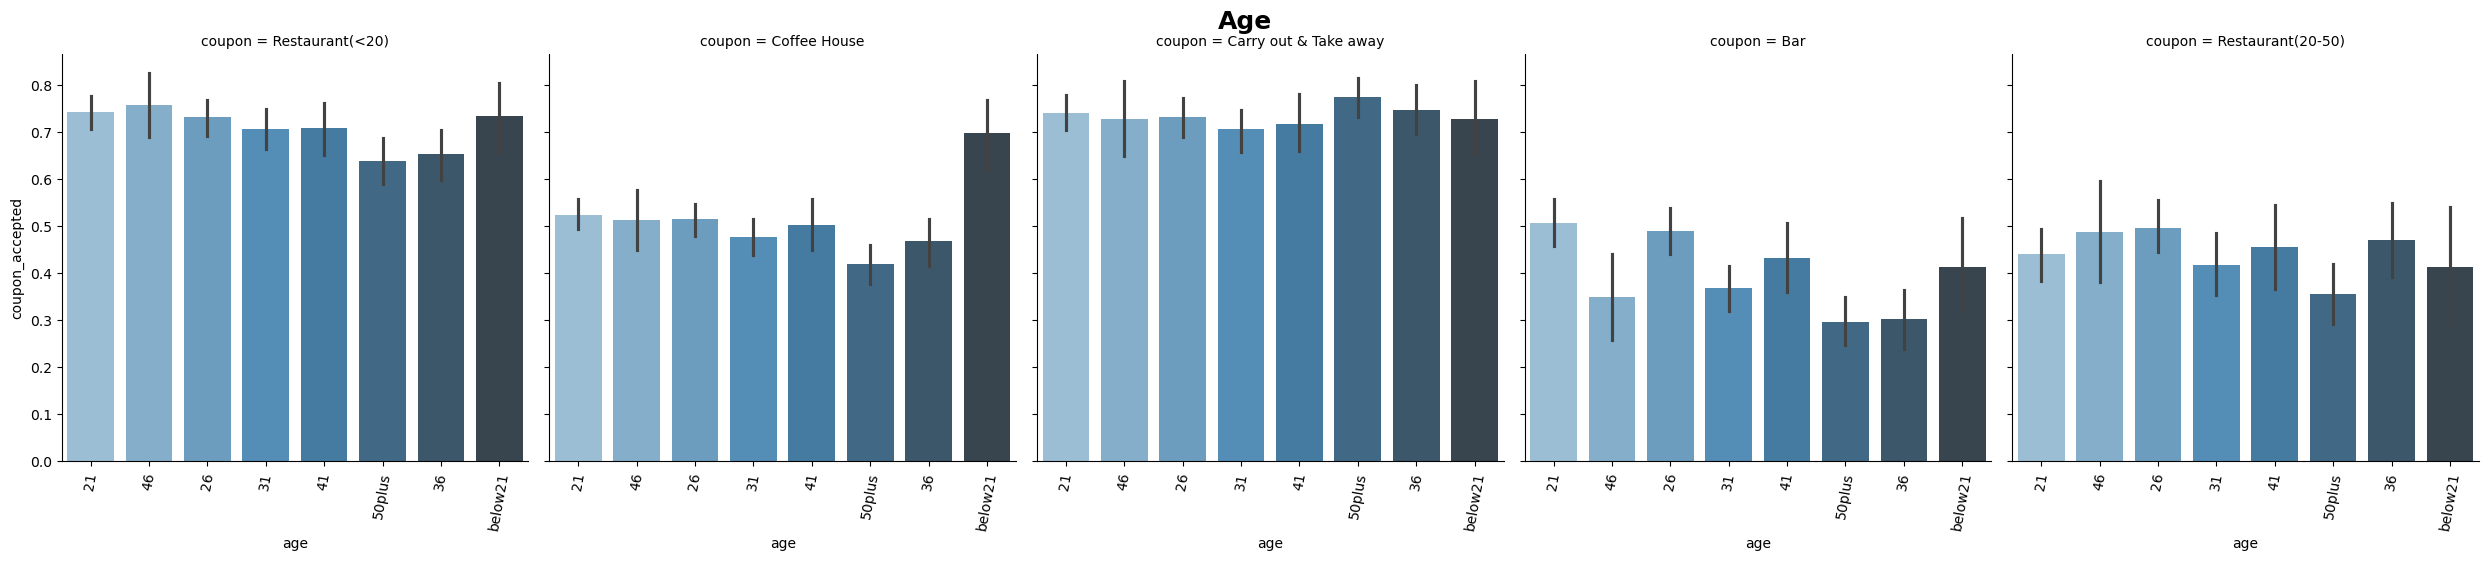

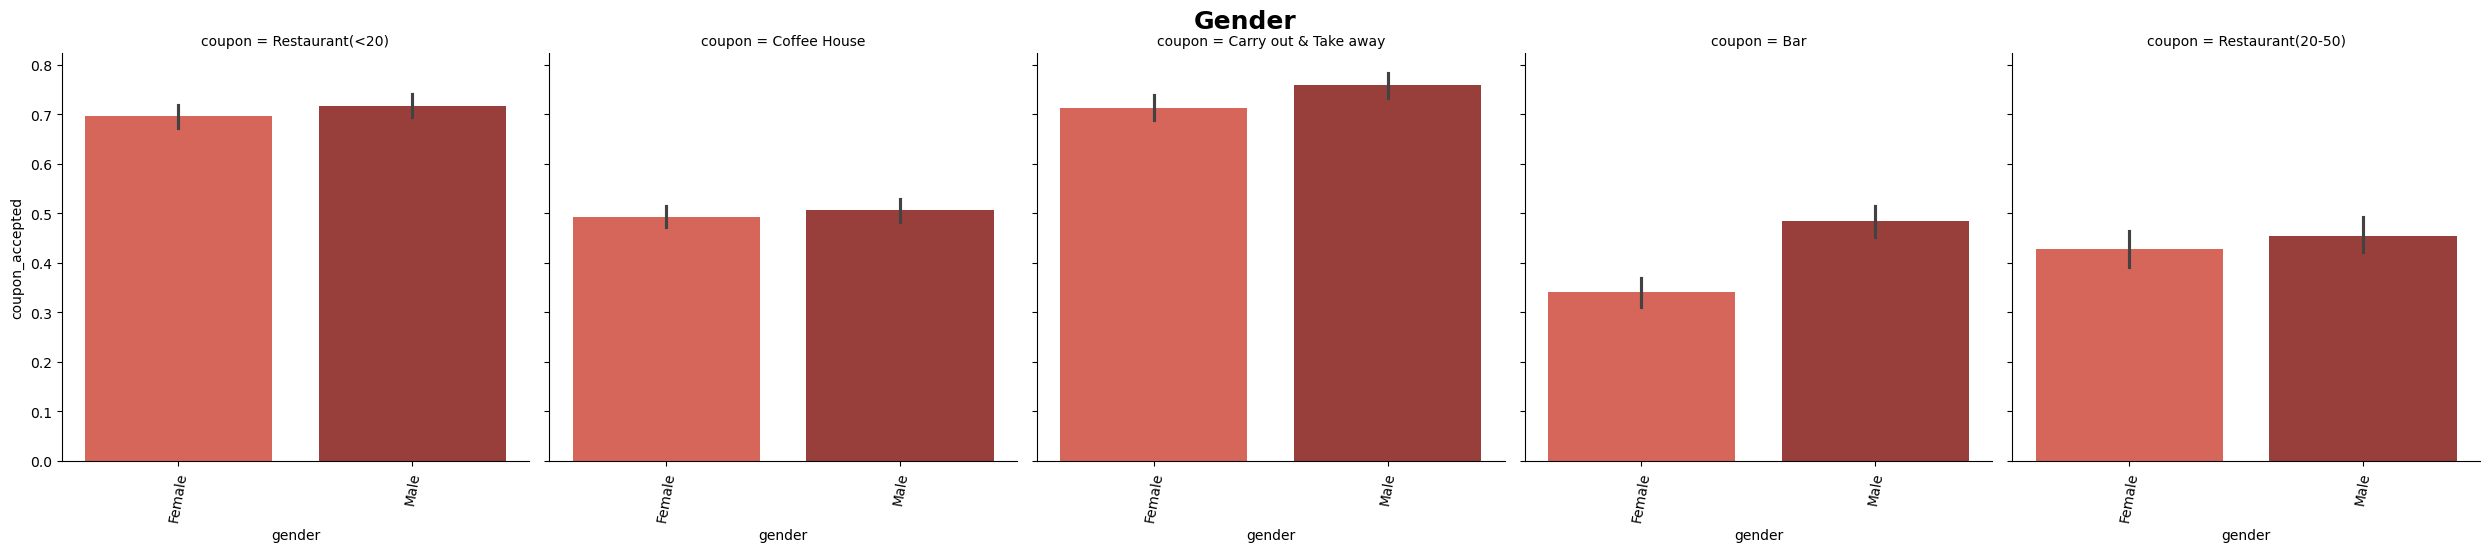

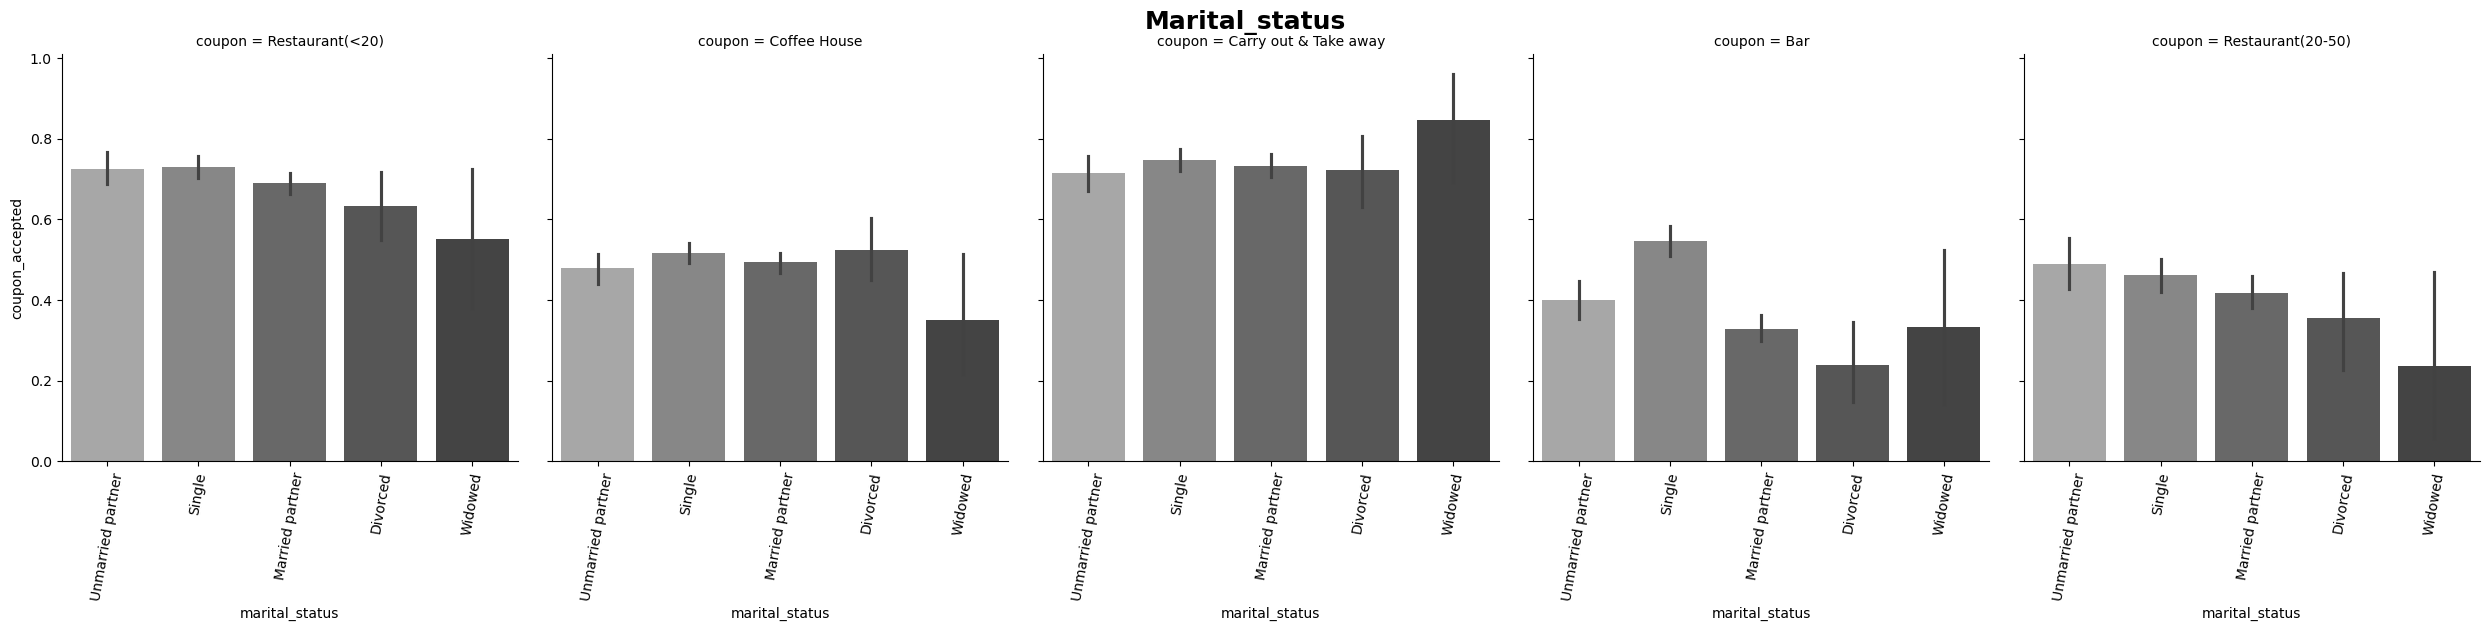

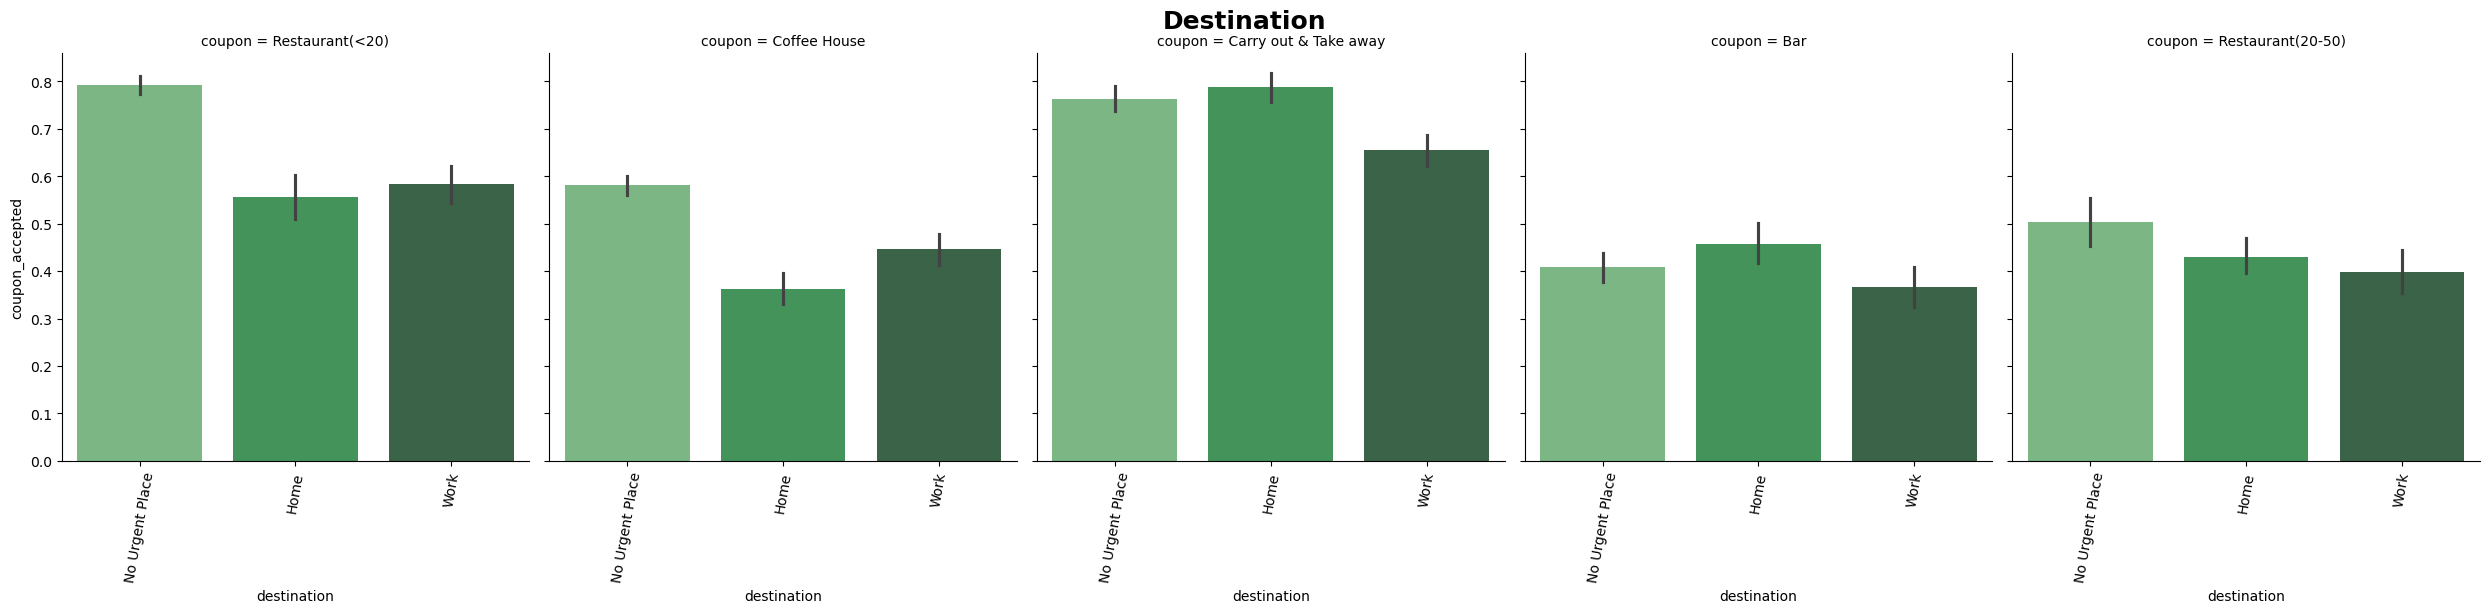

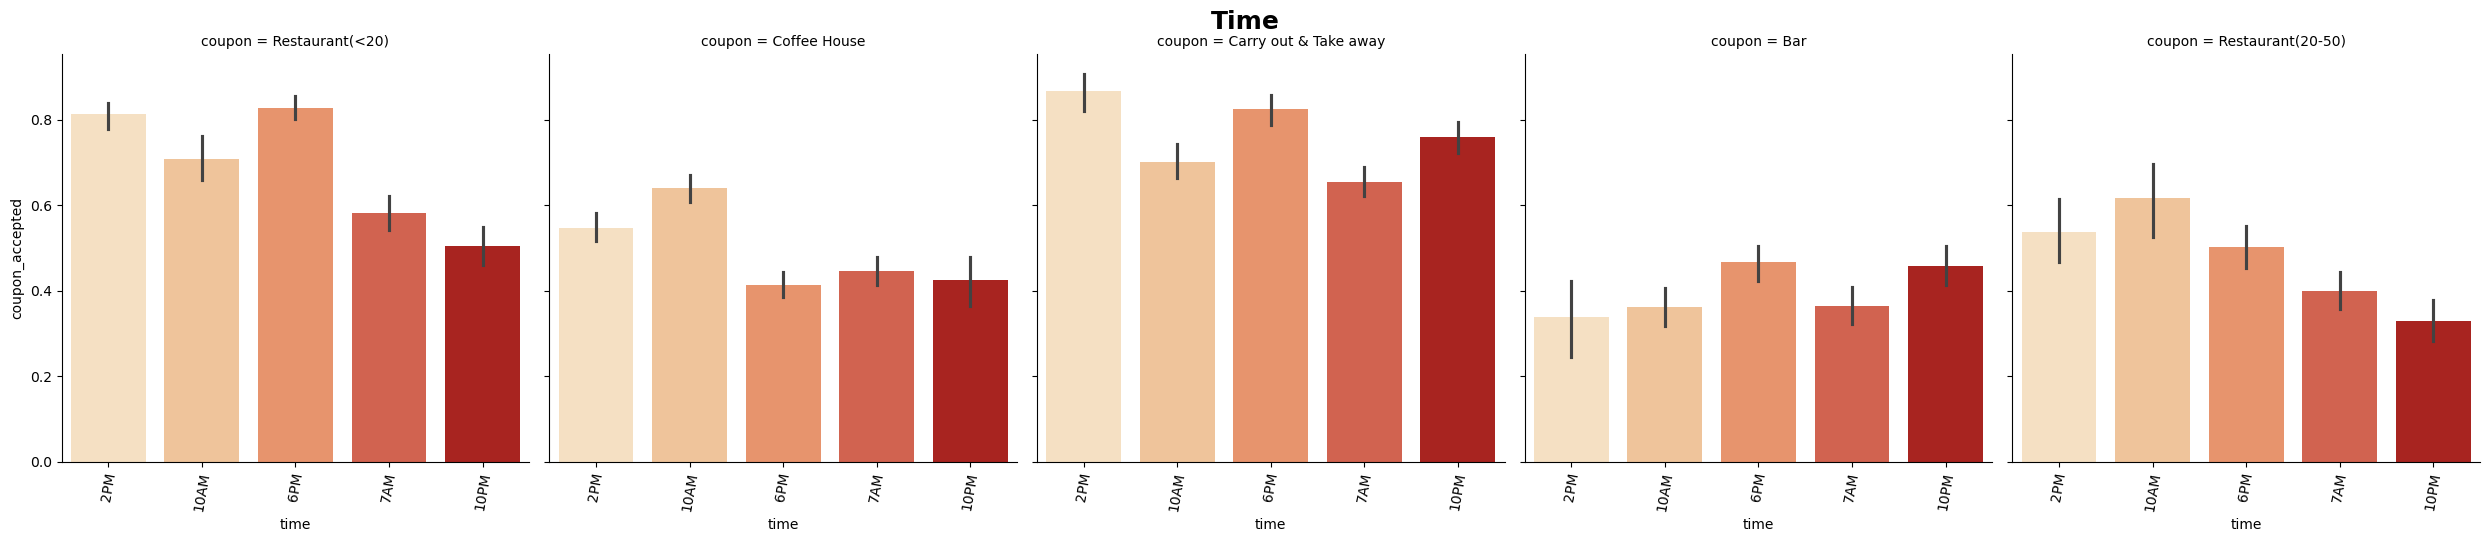

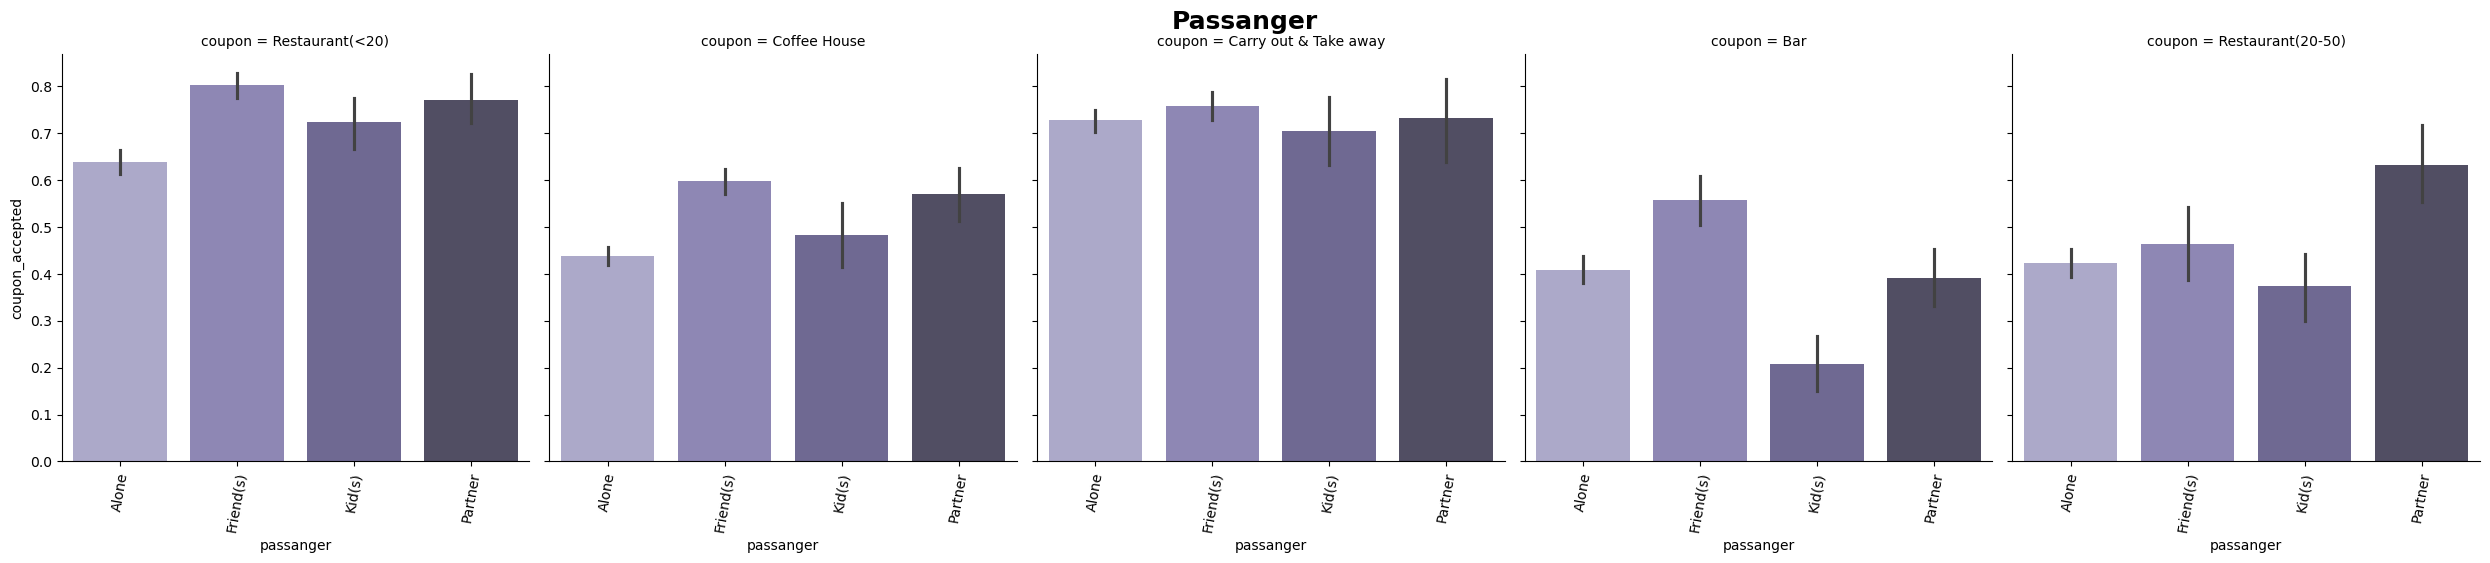

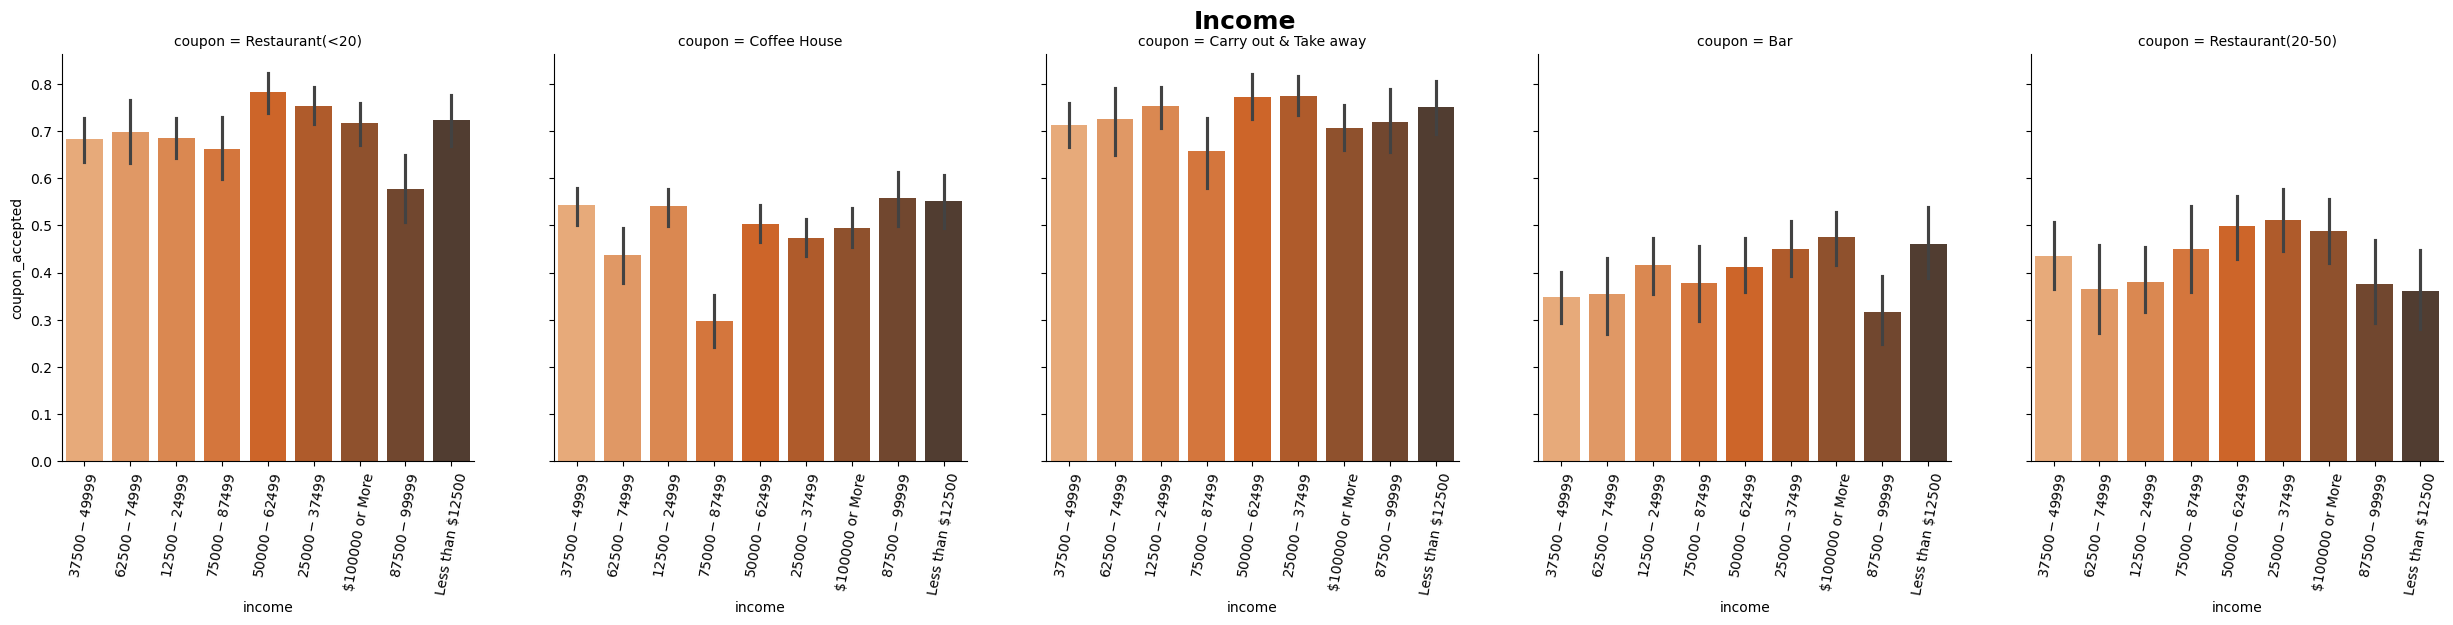

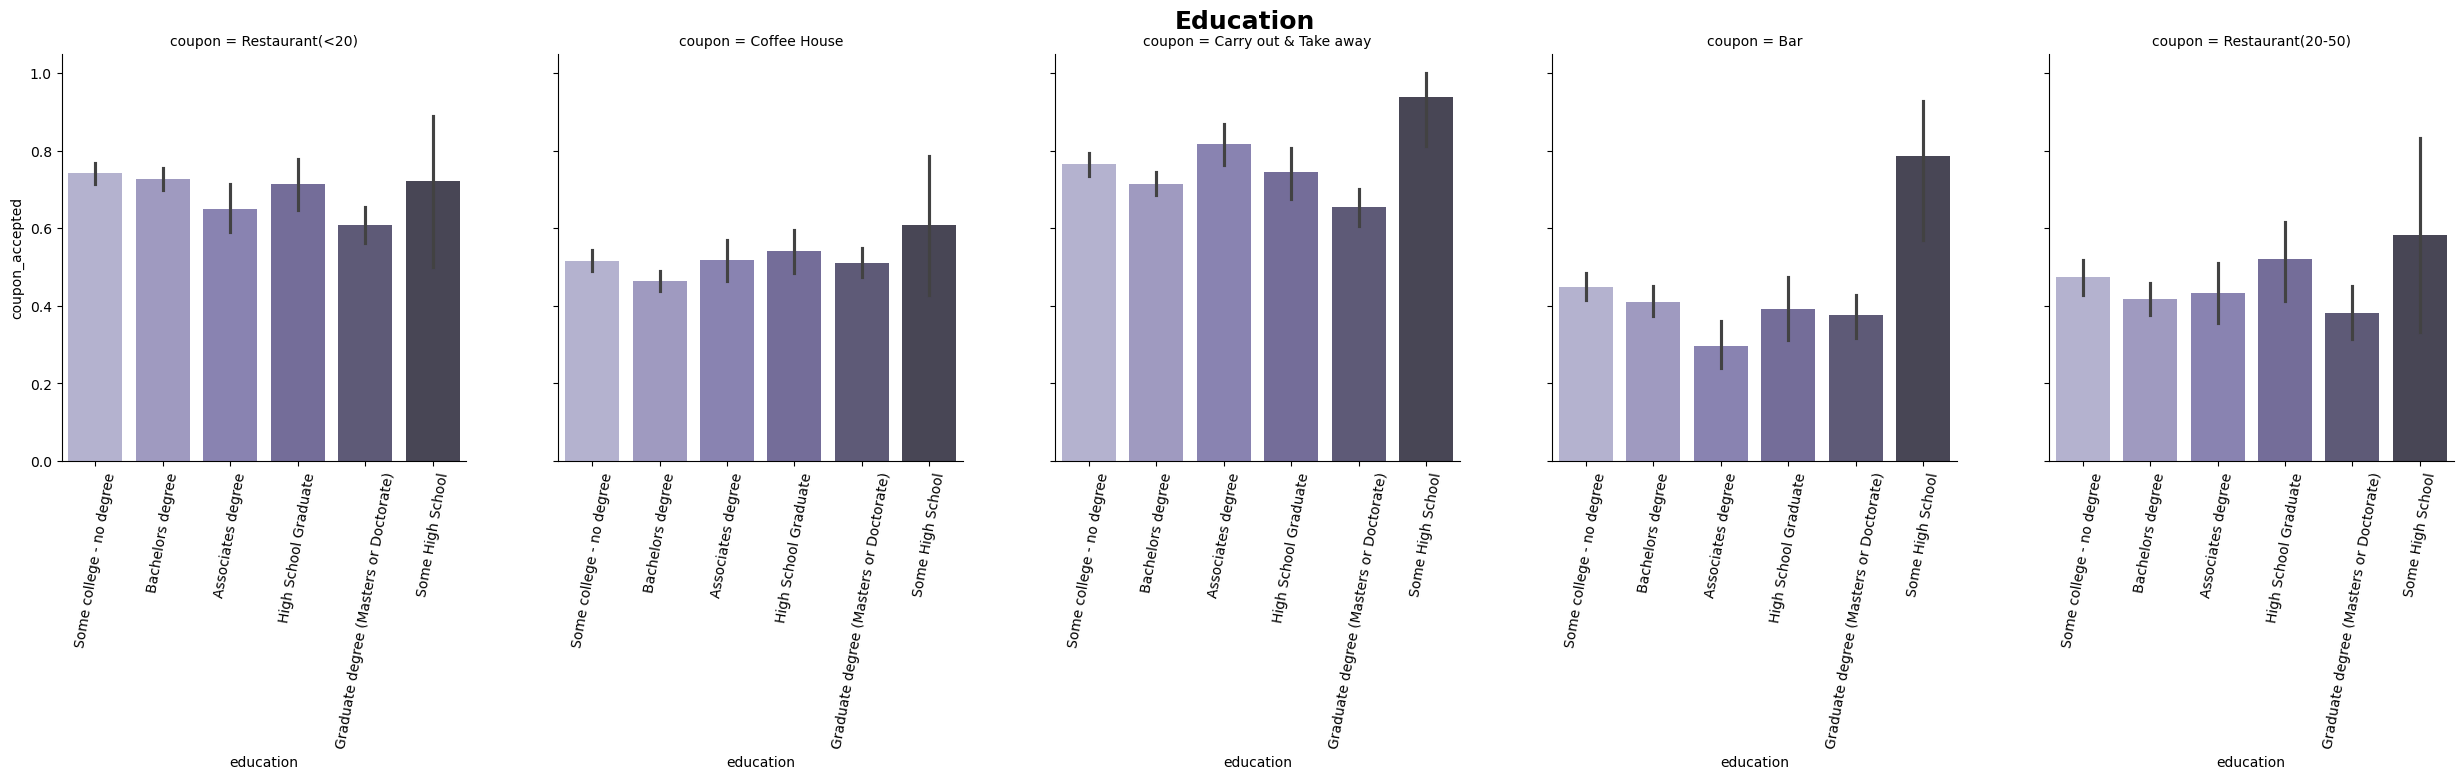

In [544]:
# Compare Coffee coupon acceptance against other coupon types for few categories
# plot coupon acceptance rate against various categories

categories = ['age', 'gender', 'marital_status', 'destination', 'time', 'passanger', 'income', 'education']
colors = ['steelblue', 'coral', 'mediumseagreen', 'olive', 'orchid', 'goldenrod', 'teal', 'pink']
palettes = ['Blues_d', 'Reds_d', 'Greys_d', 'Greens_d', 'OrRd', 'Purples_d', 'Oranges_d', 'Purples_d']

for i, c in enumerate(categories):
    g = sns.catplot(data=data, 
                    x=c, 
                    y='coupon_accepted', 
                    col='coupon', 
                    kind='bar', 
                    palette=palettes[i], 
                    hue=c, legend=False, 
                    estimator=np.mean)
    g.set_xticklabels(rotation=80)
    g.figure.suptitle(c.capitalize(), y=1.02, fontsize=18, fontweight='bold')


(array([0, 1, 2]),
 [Text(0, 0, 'Rainy'), Text(1, 0, 'Snowy'), Text(2, 0, 'Sunny')])

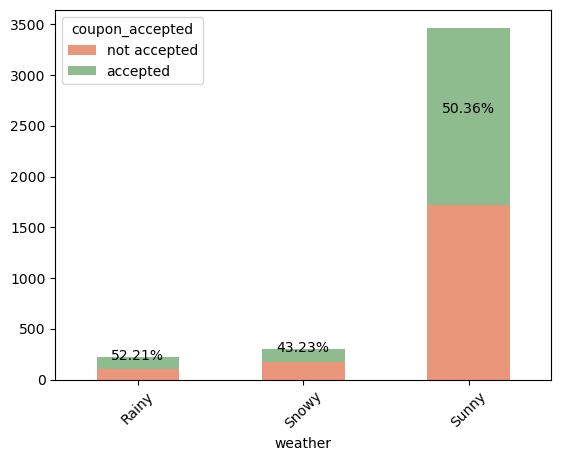

In [545]:
# what is the weather affect on the coffee_house coupon acceptance rate

df_ch = data.query('coupon == "Coffee House"')
df = df_ch.groupby('weather')[['coupon_accepted']].value_counts().unstack().reset_index()
df.rename(columns={0:'not accepted', 1:'accepted'}, inplace=True)

ax = df.plot(kind='bar', x='weather', stacked=True, color=['darksalmon', 'darkseagreen'])
df['total'] = df['accepted'] + df['not accepted']
df['mean_pct'] = (df['accepted']/df['total']*100).round(2)

for i, row in df.iterrows():
    ax.text(
        i,
        row['not accepted'] + row['accepted']/2,
        f"{row['mean_pct']}%", 
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.xticks(rotation = 45)



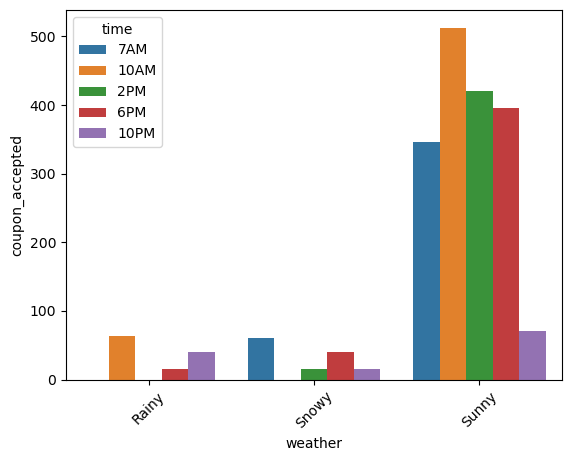

In [546]:
# At what time coffee coupons are used most?
df_grouped = df_ch.groupby(['weather', 'time'])['coupon_accepted'].sum().reset_index()
sns.barplot(
    data=df_grouped,
    x='weather',
    y='coupon_accepted',
    hue='time',
    hue_order=['7AM', '10AM', '2PM', '6PM', '10PM']
)

plt.xticks(rotation=45)
plt.show()


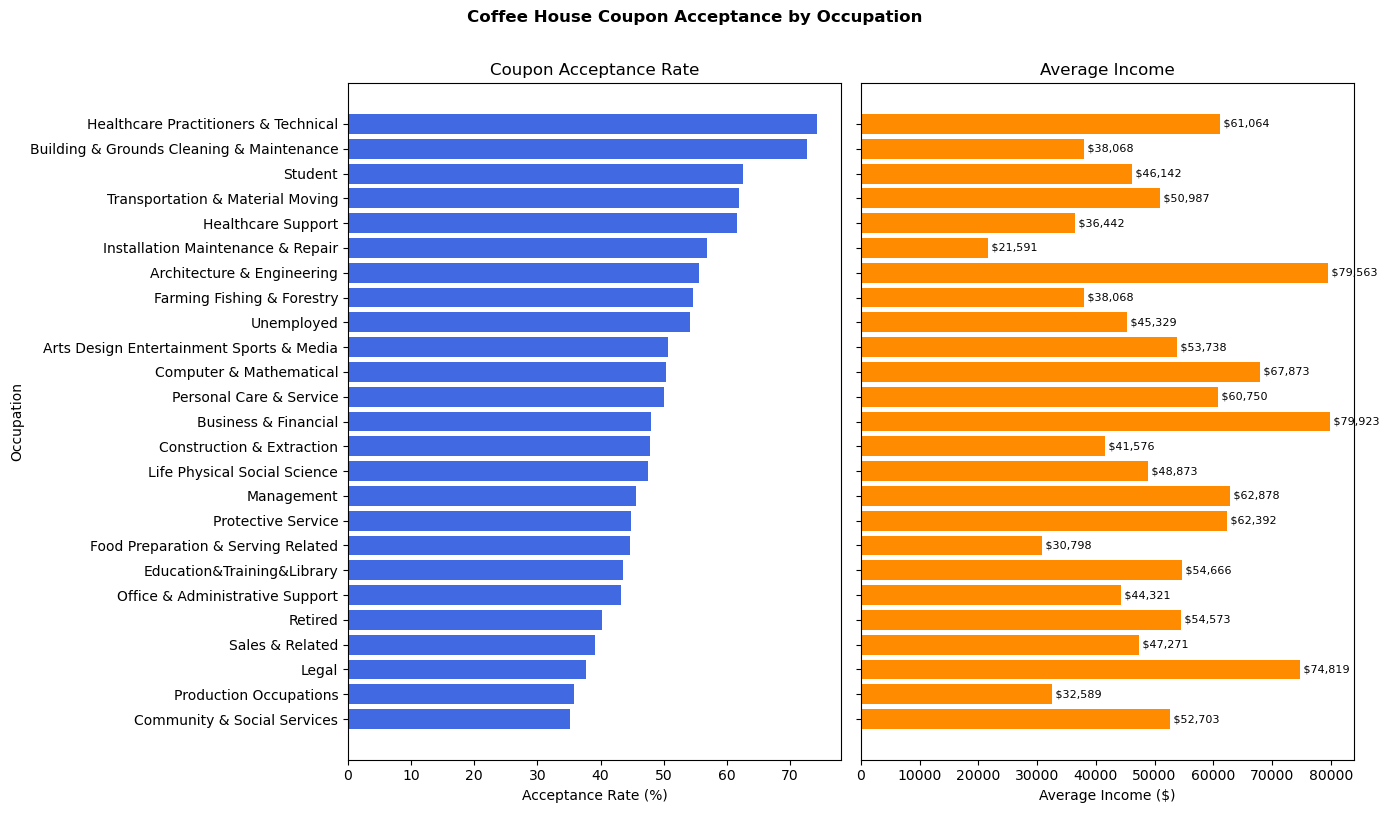

In [547]:
# Drivers of what occupation are more likely to accept coffee house coupons

# convert string income column to a numeric column
income_map = {
    'Less than $12500': 6250,
    '$12500 - $24999': 18750,
    '$25000 - $37499': 31250,
    '$37500 - $49999': 43750,
    '$50000 - $62499': 56250,
    '$62500 - $74999': 68750,
    '$75000 - $87499': 81250,
    '$87500 - $99999': 93750,
    '$100000 or More': 112500
}

df_ch2 = df_ch.copy()
df_ch2['income_numeric'] = df_ch2['income'].map(income_map)

# calculate coupon acceptance rate and ave income
df_rate = (df_ch2.groupby("occupation")['coupon_accepted'].mean() * 100).round(2)
df_income = df_ch2.groupby("occupation")['income_numeric'].mean().round(0)

# combined the two dataframes to build a df sorted by acceptance rate
df = pd.concat([df_rate, df_income], axis=1).reset_index()
df.columns = ['occupation', 'coupon_accepted', 'avg_income']
df.sort_values('coupon_accepted', inplace=True)

# Plot horizontal bar graphs
fig, axes = plt.subplots(ncols=2, figsize=(14, 8), sharey=True)

# Left: acceptance rate
axes[0].barh(df['occupation'], df['coupon_accepted'], color='royalblue')
axes[0].set_xlabel('Acceptance Rate (%)')
axes[0].set_ylabel('Occupation')
axes[0].set_title('Coupon Acceptance Rate')

# Right: avg income
axes[1].barh(df['occupation'], df['avg_income'], color='darkorange')
axes[1].set_xlabel('Average Income ($)')
axes[1].set_title('Average Income')

# Add income value labels on the right panel
for i, val in enumerate(df['avg_income']):
    axes[1].text(val, i, f' ${val:,.0f}', va='center', fontsize=8)

plt.suptitle('Coffee House Coupon Acceptance by Occupation', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

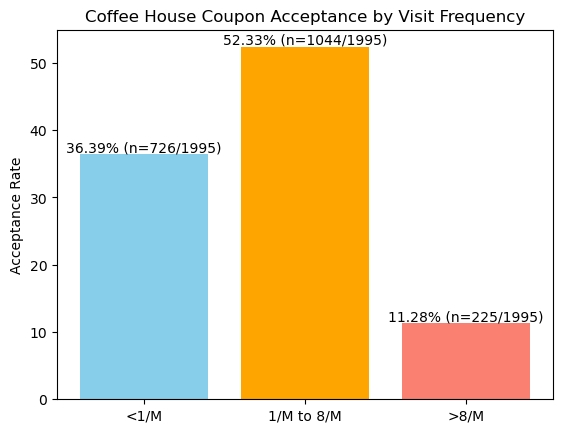

In [548]:
# What percentage of coffee coupons are accepted by various kids of coffee house
s_lessfq = ['never', 'less1']
s_medfq = ['1~3', '4~8']
s_morefq = ['gt8']

total_ch_accepted = df_ch['coupon_accepted'].sum() # value = 1995

df_lessfq = df_ch.query('coffee_house in @s_lessfq')
df_medfq = df_ch.query('coffee_house in @s_medfq')
df_morefq = df_ch.query('coffee_house in @s_morefq')

rate1 = (df_lessfq['coupon_accepted'].sum() / total_ch_accepted * 100).round(2)
rate2 = (df_medfq['coupon_accepted'].sum() / total_ch_accepted * 100).round(2)
rate3 = (df_morefq['coupon_accepted'].sum() / total_ch_accepted * 100).round(2)

labels = ['<1/M', '1/M to 8/M', '>8/M']
acpt_rates = [rate1, rate2, rate3]

sum_accepted = [df_lessfq['coupon_accepted'].sum(), 
                df_medfq['coupon_accepted'].sum(),
                df_morefq['coupon_accepted'].sum()
]

total_coupons = [total_ch_accepted, total_ch_accepted, total_ch_accepted]

fig, ax = plotacceptancerates(labels, 
                       acpt_rates, 
                       sum_accepted, 
                       total_coupons, 
                       ['skyblue', 'orange', 'salmon'],
                       'Coffee House Coupon Acceptance by Visit Frequency')

plt.show()

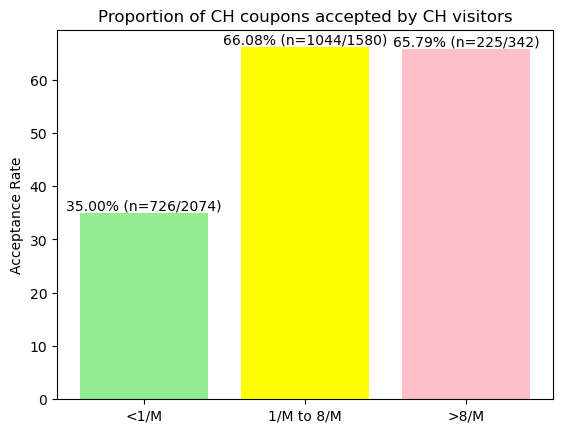

In [549]:
# Proportion of frequent coffee house visitors that accept the coupon
rate1 = (df_lessfq['coupon_accepted'].mean()*100).round(2)
rate2 = (df_medfq['coupon_accepted'].mean()*100).round(2)
rate3 = (df_morefq['coupon_accepted'].mean()*100).round(2)

acpt_rates = [rate1, rate2, rate3]

total_coupons = [len(df_lessfq), len(df_medfq), len(df_morefq)]

fig, ax = plotacceptancerates(labels, 
                       acpt_rates, 
                       sum_accepted, 
                       total_coupons, 
                       ['lightgreen', 'yellow', 'pink'],
                       'Proportion of CH coupons accepted by CH visitors')

plt.show()

In [550]:
# what effect does having kids or passengers have any on coffee house coupon acceptance

# what proportions of coffee house coupons were accepted by drivers who have children,
# with and without passengers

df_ch.groupby(['has_children', 'passanger'])['coupon_accepted'].value_counts() # observe the data

has_children  passanger  coupon_accepted
0             Alone      0                  777
                         1                  606
              Friend(s)  1                  471
                         0                  316
              Kid(s)     1                    4
              Partner    1                  157
                         0                  115
1             Alone      0                  491
                         1                  382
              Friend(s)  1                  262
                         0                  179
              Kid(s)     0                  107
                         1                   96
              Partner    1                   17
                         0                   16
Name: count, dtype: Int64

Text(0.5, 1.0, "Having kids and Passengers' effect on CH Coupon Acceptance")

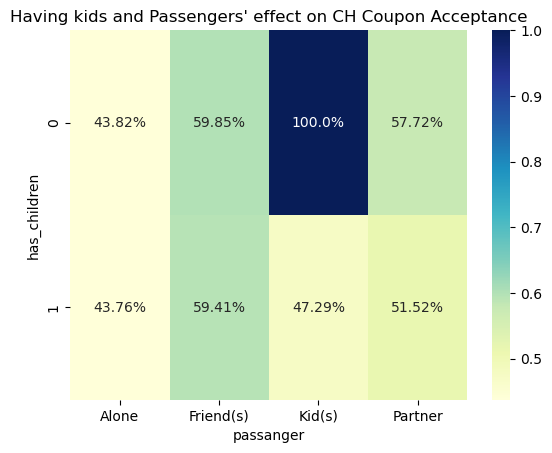

In [551]:
# plot a heat map to visualize the coupon acceptance proportions

#create a pivot table 
df_pivot = df_ch.pivot_table(
    index='has_children',
    columns='passanger',
    values='coupon_accepted',
    aggfunc='mean'
)

df_pivot = df_pivot.astype(float) #conver the data types to float that Seaborn package understands
labels = np.round(df_pivot*100, 2).astype(str) + '%' #create readable labels

sns.heatmap(df_pivot, annot=labels, fmt="", cmap='YlGnBu')
plt.title("Having kids and Passengers' effect on CH Coupon Acceptance")


#### Conclusions
Based on the observations above, I came to the following conclusions about who is more likely to accept Coffe House coupons:

1. **Frequent Coffee House Visitors**: Coffee House coupon is widely accepted by drivers if they visit the coffee house at least once per month. 
2. **Weather Impack**: Coffee House coupons are accepted more on Sunny days.
3. **Occupation**: It appears people working in Healthcare industry, Students, Transportation and Building Maintenance are frequent acceptors of the coupon.

Additional Insights:
* **Younger Demographic**: Drives below 21 are the largest demographic that accepts the coupon and by and large there isn't much difference between other age groups.
* **Passenger Context**: Similarly Drivers with all kinds of passengers are equally likely to accept the coffe hosue coupons.
* **Income Level**: Income level has no impact on the coupon acceptance rate not does having or not not having kids.

> **Final Summary**: Overall, anybody who visits coffee house at least once is likely to accept the coupon on a sunny day.